In [1]:
import seaborn as sns
import matplotlib. pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("cars.csv")
df.describe()

#x = df.iloc[:,0:13]   # variables affecting the label - leaving out address and other strings because they may not affect the label
y = df["price"]
#x = df[['year','brand','full_model_name','model_name','distance_travelled(kms)','fuel_type','city','brand_rank','car_age']]
x = df[['year','brand','model_name','distance_travelled(kms)','fuel_type','city','brand_rank','car_age']]
#print(x,y)

In [2]:
def cm(df,col):
    label_encoder = LabelEncoder()
    c = df[col]
    encoded_data = label_encoder.fit_transform(c)
    df[col] = encoded_data

for d in x:
    d1_data = x[d]
    t = type((d1_data[0]))
    if t is str:
        cm(x,d)
print(x)

      year  brand  model_name  distance_travelled(kms)  fuel_type  city  \
0     2016      7          28                   9680.0          3     9   
1     2012     23         129                 119120.0          1     9   
2     2017     28          69                  64593.0          1    14   
3     2017     21          51                  25000.0          1     9   
4     2012      8         144                  23800.0          1     9   
...    ...    ...         ...                      ...        ...   ...   
1720  2015      8          59                  38000.0          3    13   
1721  2011      2          41                  36000.0          3    13   
1722  2008     19          96                 142522.0          1    13   
1723  1990     18          89                  18581.0          1    13   
1724  2017      8          45                  31028.0          1    13   

      brand_rank  car_age  
0              7      5.0  
1             11      9.0  
2              

C:\Users\SiyaPransh\AppData\Local\Temp\ipykernel_2632\3204829729.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoded_data
C:\Users\SiyaPransh\AppData\Local\Temp\ipykernel_2632\3204829729.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoded_data
C:\Users\SiyaPransh\AppData\Local\Temp\ipykernel_2632\3204829729.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

<Figure size 1000x800 with 0 Axes>

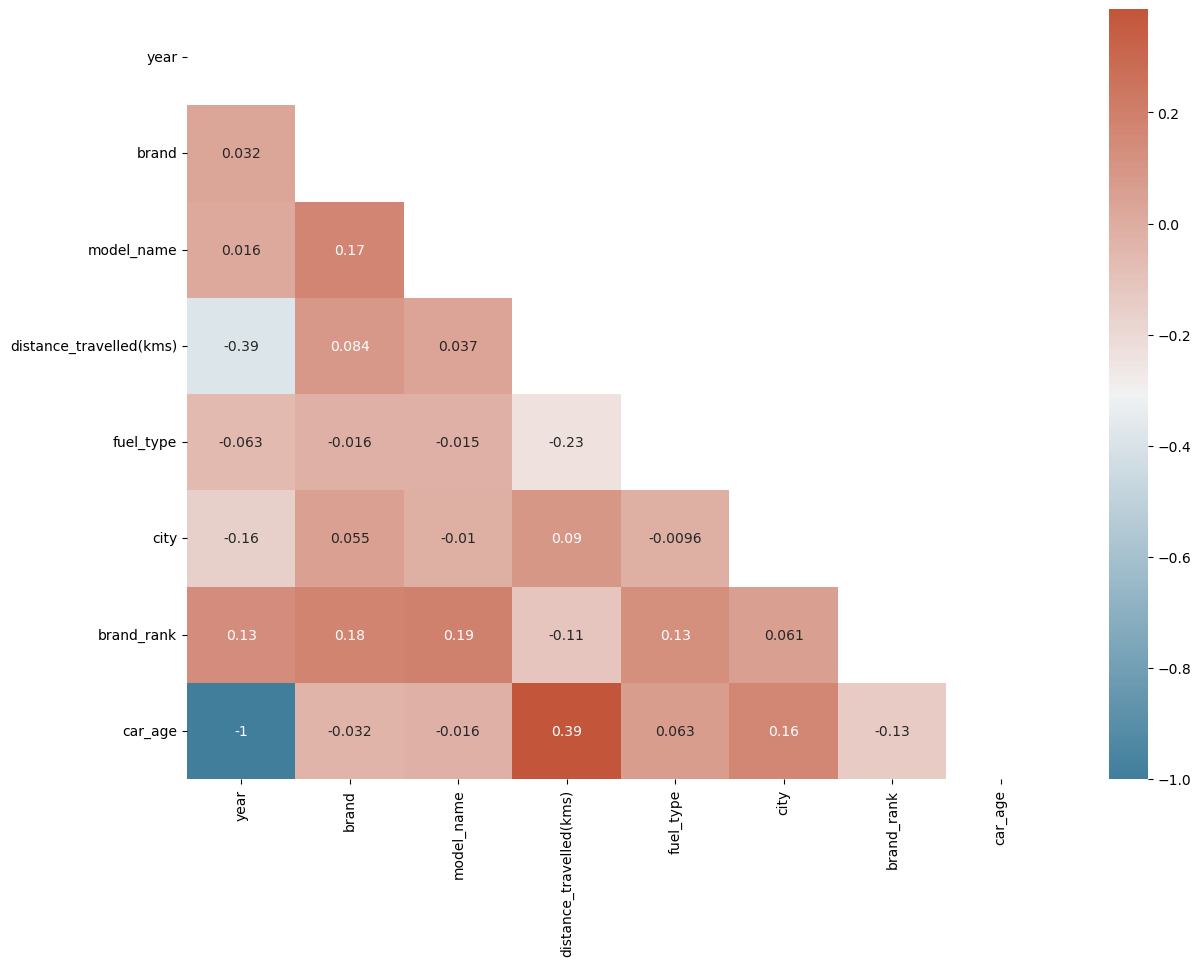

In [3]:
# Calculate the correlation matrix
import numpy as np
corr = x.corr()
# Create the heatmap
plt.figure(figsize = (10,8))
f, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, cmap = cmap, mask =  mask)
plt.show()

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)
from sklearn.metrics import mean_squared_error, r2_score
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler.
scaler = StandardScaler()

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(x_train)

# Also transform test data.
X_test_scaled = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_y = lr.predict(X_test_scaled)
# Calculate and print errors.
r2 = r2_score(y_test, pred_y)
print(f"R-squared: {r2:.4f}")


mse = mean_squared_error(y_test, pred_y)
print(f"Mean squared error: {mse:.4f}")


rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

R-squared: 0.2553
Mean squared error: 1948544942464.4761
Root mean squared error: 1395902.9130


In [8]:
# When multiple features are highly correlated, they are redundant, meaning that they are essentially giving the model the same information. 
# This situation is referred to as multicollinearity. While multicollinearity doesn’t always impact the accuracy of predictive models, 
# it complicates feature selection and interpretation, especially in linear regression and related models.

from statsmodels.stats.outliers_influence import variance_inflation_factor

corr_matrix = x.corr()
# Identify pairs of features with high collinearity (correlation > 0.8 or < -0.8).
high_corr_features = [(col1, col2, corr_matrix.loc[col1, col2])
                     for col1 in corr_matrix.columns
                     for col2 in corr_matrix.columns
                     if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > 0.8]

# Convert to a DataFrame for better visualization.
c_df = pd.DataFrame(high_corr_features, columns=["Feature 1", "Feature 2", "Correlation"])
print("\nHighly Correlated Features:\n", c_df)

# Compute Variance Inflation Factor (VIF) for each feature.
vif_data = pd.DataFrame()
vif_data["Feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

# Print VIF values.
print("\nVariance Inflation Factor (VIF) for each feature:\n", vif_data)


Highly Correlated Features:
   Feature 1 Feature 2  Correlation
0      year   car_age         -1.0
1   car_age      year         -1.0

Variance Inflation Factor (VIF) for each feature:
                    Feature        VIF
0                     year  14.420129
1                    brand   1.068901
2               model_name   1.062781
3  distance_travelled(kms)   1.293875
4                fuel_type   1.107445
5                     city   1.038133
6               brand_rank   1.113233
7                  car_age   5.092171


In [9]:
# Let's remove 'year' from the model.

y = df["price"]
x = df[['brand','model_name','distance_travelled(kms)','fuel_type','city','brand_rank','car_age']]

def cm(df,col):
    label_encoder = LabelEncoder()
    c = df[col]
    encoded_data = label_encoder.fit_transform(c)
    df[col] = encoded_data

for d in x:
    d1_data = x[d]
    t = type((d1_data[0]))
    if t is str:
        cm(x,d)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)
from sklearn.metrics import mean_squared_error, r2_score
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler.
scaler = StandardScaler()

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(x_train)

# Also transform test data.
X_test_scaled = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_y = lr.predict(X_test_scaled)
# Calculate and print errors.
r2 = r2_score(y_test, pred_y)
print(f"R-squared: {r2:.4f}")


mse = mean_squared_error(y_test, pred_y)
print(f"Mean squared error: {mse:.4f}")


rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

R-squared: 0.1344
Mean squared error: 2036550308448.8577
Root mean squared error: 1427077.5411


C:\Users\SiyaPransh\AppData\Local\Temp\ipykernel_2632\523278946.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoded_data
C:\Users\SiyaPransh\AppData\Local\Temp\ipykernel_2632\523278946.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoded_data
C:\Users\SiyaPransh\AppData\Local\Temp\ipykernel_2632\523278946.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

Intercept: 1505634.420289855

Feature Coefficients:
                    Feature    Coefficient
0                    brand -146620.877963
1               model_name  -64259.126513
2  distance_travelled(kms) -215894.360050
3                fuel_type -407264.638206
4                     city  -30274.573537
5               brand_rank -266587.125298
6                  car_age -433326.190104


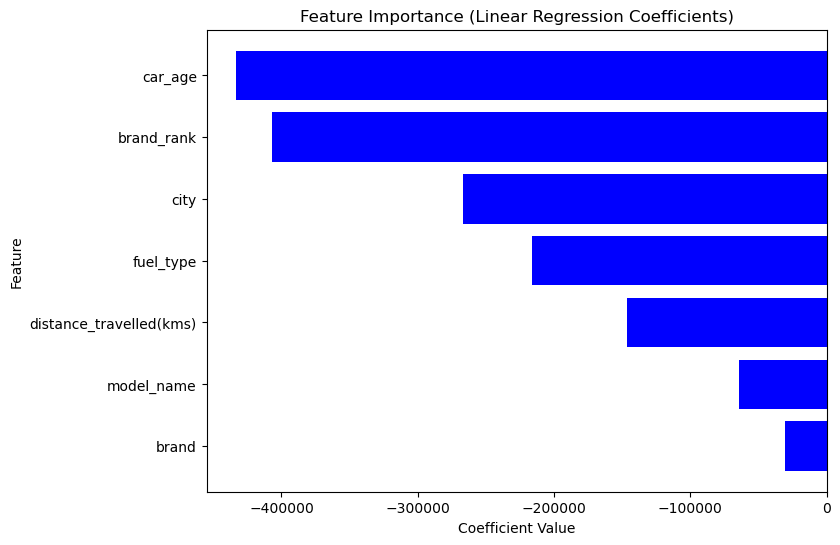

In [16]:
# Extracting Model Insights

print("Intercept:", lr.intercept_)
coeff_df = pd.DataFrame({"Feature": x.columns, "Coefficient": lr.coef_})
print("\nFeature Coefficients:\n", coeff_df)
# Sort dataframe by coefficients.
coeff_df_sorted = coeff_df.sort_values(by="Coefficient", ascending=False)
# Create plot.
plt.figure(figsize=(8,6))
plt.barh(coeff_df["Feature"], coeff_df_sorted["Coefficient"], color="blue")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()